In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load raw data
df = pd.read_csv("../data/raw/fraud_detection_cdr.csv")


df = df.drop(columns=['Phone Number'])

print("Shape:", df.shape)
print("Fraud distribution:\n", df['isFraud'].value_counts(normalize=True).round(3))
df.head()

Shape: (101174, 16)
Fraud distribution:
 isFraud
False    0.896
True     0.104
Name: proportion, dtype: float64


,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,isFraud
0,128,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
baseline = df.groupby('isFraud').mean().T
baseline.columns = ['Legit', 'Fraud']
baseline['Difference %'] = ((baseline['Fraud'] - baseline['Legit']) / baseline['Legit'] * 100).round(1)
baseline = baseline.sort_values('Difference %', ascending=False)
print(baseline)

                     Legit       Fraud  Difference %
Day Mins        570.329984  731.244045          28.2
Eve Mins        639.999380  789.023978          23.3
Night Mins      631.440004  778.865084          23.3
Account Length  316.179089  387.439518          22.5
Intl Mins        19.986469   22.914480          14.6
Day Calls       264.215982  292.954615          10.9
Eve Calls       264.212429  292.594379          10.7
Night Calls     258.804153  286.365078          10.6
CustServ Calls    2.536925    2.755127           8.6
Eve Charge       34.113644   36.462208           6.9
Day Charge       64.642064   67.684846           4.7
Intl Charge       4.333314    4.470883           3.2
Night Charge     13.931364   13.631432          -2.2
Intl Calls        5.763487    5.516711          -4.3
VMail Message    18.789325   12.577098         -33.1


In [3]:
# --- FEATURE GROUP 1: Call Volume & Intensity ---

# F1: Total calls across all time periods
df['total_calls'] = df['Day Calls'] + df['Eve Calls'] + df['Night Calls'] + df['Intl Calls']

# F2: Total minutes across all time periods
df['total_mins'] = df['Day Mins'] + df['Eve Mins'] + df['Night Mins'] + df['Intl Mins']

# F3: Total charge across all time periods
df['total_charge'] = df['Day Charge'] + df['Eve Charge'] + df['Night Charge'] + df['Intl Charge']

# F4: Average call duration (mins per call) - robocallers have very short or very long calls
df['avg_call_duration'] = df['total_mins'] / (df['total_calls'] + 1e-9)

# F5: Call intensity score - high calls + high mins = aggressive caller
df['call_intensity'] = df['total_calls'] * df['total_mins']

print("Volume features created ✅")
df[['total_calls','total_mins','total_charge','avg_call_duration','call_intensity']].describe()

Volume features created ✅


,total_calls,total_mins,total_charge,avg_call_duration,call_intensity
count,101174.000000,101174.000000,101174.000000,101174.000000,1.011740e+05
mean,801.785528,1909.671237,117.564712,2.921415,3.299788e+06
std,1691.487687,4618.564621,147.842702,6.785637,2.140025e+07
min,74.000000,270.800000,19.120000,0.026330,3.717480e+04
25%,367.000000,711.700000,63.120000,1.352203,2.827668e+05
50%,518.000000,802.000000,78.360000,1.700800,4.048632e+05
75%,664.000000,1365.200000,127.790000,2.382857,8.457208e+05
max,42430.000000,132466.530000,1535.750000,277.818904,1.042600e+09


In [4]:
# --- FEATURE GROUP 2: Charge Efficiency / Anomaly ---

# F6: Charge per minute - should be roughly constant for legit users
# Anomaly here = unusual billing pattern
df['charge_per_min'] = df['total_charge'] / (df['total_mins'] + 1e-9)

# F7: Day charge ratio - what % of total charge happens during day
df['day_charge_ratio'] = df['Day Charge'] / (df['total_charge'] + 1e-9)

# F8: International charge ratio - high intl charge = suspicious
df['intl_charge_ratio'] = df['Intl Charge'] / (df['total_charge'] + 1e-9)

print("Charge features created ✅")
df[['charge_per_min','day_charge_ratio','intl_charge_ratio']].describe()

Charge features created ✅


,charge_per_min,day_charge_ratio,intl_charge_ratio
count,101174.000000,101174.000000,101174.000000
mean,0.104939,0.479574,0.048647
std,0.100131,0.160074,0.032633
min,0.000952,0.000000,0.000000
25%,0.076018,0.370946,0.029961
50%,0.094343,0.448428,0.041273
75%,0.111519,0.590776,0.058435
max,2.130156,0.988232,0.299503


In [5]:
# --- FEATURE GROUP 3: International Call Behaviour ---

# F9: International call ratio - intl calls as % of total calls
df['intl_call_ratio'] = df['Intl Calls'] / (df['total_calls'] + 1e-9)

# F10: International mins ratio - intl mins as % of total mins
df['intl_mins_ratio'] = df['Intl Mins'] / (df['total_mins'] + 1e-9)

# F11: Intl mins per intl call - average duration of intl calls
df['intl_avg_duration'] = df['Intl Mins'] / (df['Intl Calls'] + 1e-9)

print("International features created ✅")
df[['intl_call_ratio','intl_mins_ratio','intl_avg_duration']].describe()

International features created ✅


,intl_call_ratio,intl_mins_ratio,intl_avg_duration
count,101174.000000,101174.000000,101174.000000
mean,0.011481,0.019554,5.649727
std,0.013591,0.016058,8.738799
min,0.000000,0.000000,0.000000
25%,0.004233,0.006405,1.300000
50%,0.007299,0.016898,3.600000
75%,0.014493,0.030577,9.080000
max,0.485057,0.321114,105.950000


In [6]:
# --- FEATURE GROUP 4: Time-of-Day Usage Distribution ---

# F12: Day usage ratio - what % of total mins happen during day
df['day_usage_ratio'] = df['Day Mins'] / (df['total_mins'] + 1e-9)

# F13: Night usage ratio - spammers often call at night (lower detection)
df['night_usage_ratio'] = df['Night Mins'] / (df['total_mins'] + 1e-9)

# F14: Eve usage ratio
df['eve_usage_ratio'] = df['Eve Mins'] / (df['total_mins'] + 1e-9)

# F15: Night-to-Day ratio - high value = suspicious night activity
df['night_to_day_ratio'] = df['Night Mins'] / (df['Day Mins'] + 1e-9)

print("Time-of-day features created ✅")
df[['day_usage_ratio','night_usage_ratio','eve_usage_ratio','night_to_day_ratio']].describe()

Time-of-day features created ✅


,day_usage_ratio,night_usage_ratio,eve_usage_ratio,night_to_day_ratio
count,101174.000000,101174.000000,101174.000000,1.011740e+05
mean,0.312231,0.333413,0.334801,2.652711e+08
std,0.125261,0.122418,0.125027,1.791071e+10
min,0.000000,0.000525,0.000000,9.757854e-04
25%,0.293149,0.302842,0.302641,9.144914e-01
50%,0.322924,0.328629,0.328668,1.002703e+00
75%,0.345972,0.356951,0.357159,1.172072e+00
max,0.987612,0.988505,0.985712,2.611110e+12


In [7]:
# --- FEATURE GROUP 5: Risk Signals ---

# F16: Customer service call flag
# >3 CustServ calls = strong fraud signal (complaints from others about this number)
df['high_custserv_flag'] = (df['CustServ Calls'] > 3).astype(int)

# F17: Voicemail usage ratio - spammers rarely use voicemail
df['voicemail_ratio'] = df['VMail Message'] / (df['total_calls'] + 1e-9)

# F18: Account age risk - very new OR very old accounts behave differently
# Short account length with high call volume = suspicious
df['account_call_intensity'] = df['total_calls'] / (df['Account Length'] + 1e-9)

print("Risk signal features created ✅")
df[['high_custserv_flag','voicemail_ratio','account_call_intensity']].describe()

Risk signal features created ✅


,high_custserv_flag,voicemail_ratio,account_call_intensity
count,101174.000000,101174.000000,101174.000000
mean,0.239844,0.031862,9.586568
std,0.426990,0.117332,37.731099
min,0.000000,0.000000,0.016390
25%,0.000000,0.000000,1.884528
50%,0.000000,0.000000,3.067568
75%,0.000000,0.036036,9.500000
max,1.000000,5.215962,2326.499999


In [8]:
# --- VALIDATE: Do our engineered features actually separate fraud from legit? ---

engineered_features = [
    'total_calls', 'total_mins', 'avg_call_duration', 'call_intensity',
    'charge_per_min', 'intl_charge_ratio', 'intl_call_ratio',
    'day_usage_ratio', 'night_to_day_ratio',
    'high_custserv_flag', 'voicemail_ratio', 'account_call_intensity'
]

validation = df.groupby('isFraud')[engineered_features].mean().T
validation.columns = ['Legit', 'Fraud']
validation['Fraud/Legit Ratio'] = (validation['Fraud'] / (validation['Legit'] + 1e-9)).round(2)
validation = validation.sort_values('Fraud/Legit Ratio', ascending=False)

print("Feature Validation — Fraud vs Legit Mean Comparison:")
print(validation)

Feature Validation — Fraud vs Legit Mean Comparison:
                               Legit         Fraud  Fraud/Legit Ratio
night_to_day_ratio      2.293400e+08  5.745063e+08               2.51
call_intensity          3.212796e+06  4.048479e+06               1.26
total_mins              1.861756e+03  2.322048e+03               1.25
avg_call_duration       2.860065e+00  3.449414e+00               1.21
total_calls             7.929961e+02  8.774308e+02               1.11
intl_charge_ratio       4.825599e-02  5.201014e-02               1.08
day_usage_ratio         3.110267e-01  3.225986e-01               1.04
account_call_intensity  9.572614e+00  9.706658e+00               1.01
intl_call_ratio         1.154598e-02  1.092430e-02               0.95
high_custserv_flag      2.416429e-01  2.243638e-01               0.93
charge_per_min          1.058009e-01  9.751853e-02               0.92
voicemail_ratio         3.315426e-02  2.074096e-02               0.63


In [14]:
import os 
os.makedirs("../data/processed",exist_ok=True)

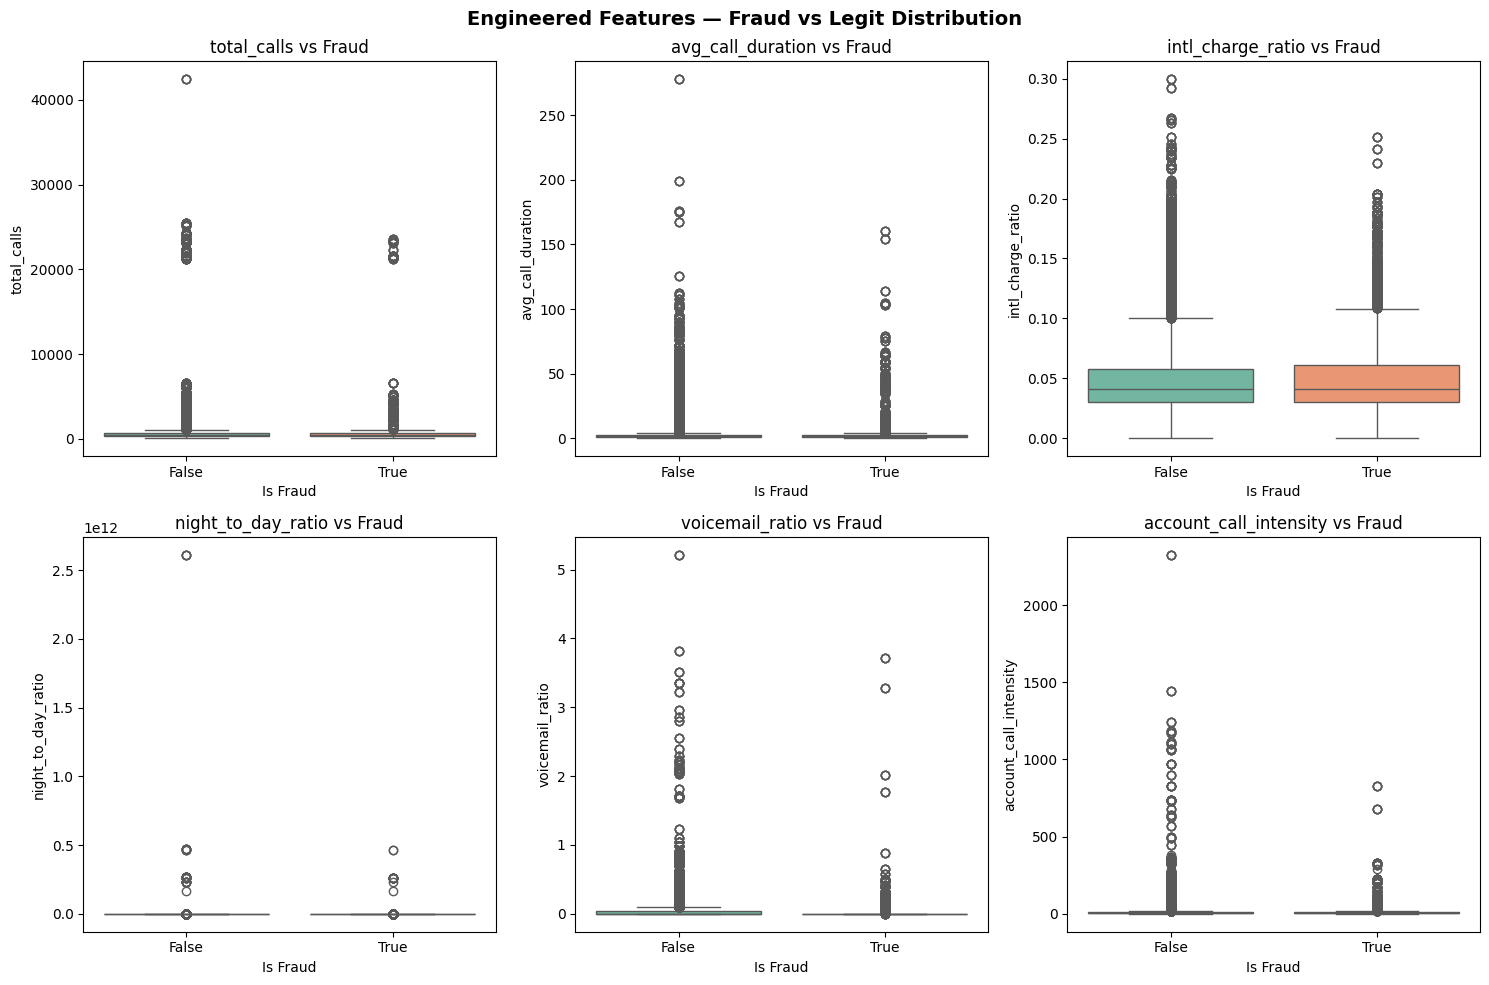

In [15]:
# Visualize top discriminative engineered features
top_features = ['total_calls', 'avg_call_duration', 'intl_charge_ratio',
                'night_to_day_ratio', 'voicemail_ratio', 'account_call_intensity']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.boxplot(x='isFraud', y=feat, data=df, ax=axes[i], 
            hue='isFraud', palette='Set2', legend=False)
    axes[i].set_title(f'{feat} vs Fraud', fontsize=12)
    axes[i].set_xlabel('Is Fraud')

plt.suptitle('Engineered Features — Fraud vs Legit Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_validation_plots.png', dpi=150)
plt.show()

In [16]:
# Drop original charge columns (redundant — just mins x rate)
charge_cols = ['Day Charge', 'Eve Charge', 'Night Charge', 'Intl Charge']
df = df.drop(columns=charge_cols, errors='ignore')  # ← sirf yahi add karna hai

# Final feature set
print("Final shape:", df.shape)
print("Total features:", df.shape[1] - 1, "(excluding target)")
print("\nAll columns:")
print(df.columns.tolist())

# Save for modelling
df.to_csv("../data/processed/cdr_features.csv", index=False)
print("\n✅ Saved to ../data/processed/cdr_features.csv")

Final shape: (101174, 30)
Total features: 29 (excluding target)

All columns:
['Account Length', 'VMail Message', 'Day Mins', 'Day Calls', 'Eve Mins', 'Eve Calls', 'Night Mins', 'Night Calls', 'Intl Mins', 'Intl Calls', 'CustServ Calls', 'isFraud', 'total_calls', 'total_mins', 'total_charge', 'avg_call_duration', 'call_intensity', 'charge_per_min', 'day_charge_ratio', 'intl_charge_ratio', 'intl_call_ratio', 'intl_mins_ratio', 'intl_avg_duration', 'day_usage_ratio', 'night_usage_ratio', 'eve_usage_ratio', 'night_to_day_ratio', 'high_custserv_flag', 'voicemail_ratio', 'account_call_intensity']

✅ Saved to ../data/processed/cdr_features.csv
